In [1]:
#imports
# For Data Processing
import numpy as np
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# For ML Models
import tensorflow as tf
from tensorflow import keras

from tensorflow.keras.layers import *
from tensorflow.keras.losses import *
from tensorflow.keras.models import *
from tensorflow.keras.metrics import *
from tensorflow.keras.optimizers import *
from tensorflow.keras.applications import *
from tensorflow.keras.utils import load_img
from tensorflow.keras.callbacks import EarlyStopping

# For Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

#miscellaneous
#from tqdm import tqdm
import os
import random
import numpy as np
import random
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import matplotlib.pyplot as plt


2026-03-11 14:46:40.775376: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-11 14:46:40.819177: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/home/ayeyushh451/miniconda3/envs/tensorflow-ml/lib/python3.13/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
2026-03-11 14:46:42.238397: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical 

In [2]:
batch_size = 8
img_height = 300
img_width = 300
data_dir = "Brain_Tumor_new/Training"
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    labels="inferred",
    label_mode="categorical",
    batch_size=batch_size,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    labels="inferred",
    label_mode="categorical",
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)


Found 8582 files belonging to 4 classes.
Using 6866 files for training.


2026-03-11 14:46:48.287619: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


Found 8582 files belonging to 4 classes.
Using 1716 files for validation.


In [3]:
for images, labels in val_ds.take(1):
    print(images.shape)
    print(labels.shape)


(8, 300, 300, 3)
(8, 4)


2026-03-11 14:46:54.877307: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [4]:
import tensorflow as tf

NUM_CLASSES = 4
IMAGE_SIZE_VGG = 224
IMAGE_SIZE_RESNET = 224

# Define augmentation layers once
vgg_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),          # left/right flip
    tf.keras.layers.RandomRotation(0.05),              # ~±18°
    tf.keras.layers.RandomZoom(0.1),                   # small zoom in/out
    tf.keras.layers.RandomTranslation(0.05, 0.05),     # shift up to 5%
    tf.keras.layers.RandomContrast(0.1),               # subtle contrast change
    tf.keras.layers.RandomBrightness(factor=0.1),            # contrast tweak
])

# Training preprocessing

# Training preprocessing
def preprocess_vgg_train(x, y):
    x = tf.image.resize(x, [IMAGE_SIZE_VGG, IMAGE_SIZE_VGG])
    x = vgg_augmentation(x)
    x = tf.keras.applications.vgg16.preprocess_input(x)  # ✅ VGG16 preprocessing
    return x, y

# Validation preprocessing
def preprocess_vgg_val(x, y):
    x = tf.image.resize(x, [IMAGE_SIZE_VGG, IMAGE_SIZE_VGG])
    x = tf.keras.applications.vgg16.preprocess_input(x)  # ✅ VGG16 preprocessing
    return x, y




In [5]:
train_ds_vgg = train_ds.map(preprocess_vgg_train, num_parallel_calls=tf.data.AUTOTUNE)
val_ds_vgg = val_ds.map(preprocess_vgg_val, num_parallel_calls=tf.data.AUTOTUNE)

train_ds_vgg = train_ds_vgg.prefetch(tf.data.AUTOTUNE)
val_ds_vgg = val_ds_vgg.prefetch(tf.data.AUTOTUNE)

In [6]:
for images, labels in train_ds_vgg.take(1):
    print(images[0].shape)  # first image in batch
    print(labels[0].shape)  # first label


(224, 224, 3)
(4,)


2026-03-11 14:33:09.325230: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [8]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, regularizers
from tensorflow.keras.applications import VGG16

NUM_CLASSES = 4
IMAGE_SIZE = 224

# Load pretrained VGG16 base
base_model = VGG16(
    include_top=False,
    weights='imagenet',
    input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3)
)

# Freeze all layers
for layer in base_model.layers:
    layer.trainable = False

# Unfreeze the last VGG block (block5)
for layer in base_model.layers:
    if layer.name.startswith("block5"):
        layer.trainable = True

# Build model
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.016)),
    layers.Dropout(0.5),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

# Compile
optimizer = optimizers.Adam(learning_rate=1e-4)
model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 8s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         2,052 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,979,396 (57.14 MB)

 Trainable params: 7,344,132 (28.02 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint
early_stop = EarlyStopping(
    monitor='val_loss',       # or 'val_accuracy' if you prefer
    patience=3,               # number of epochs with no improvement to wait
    restore_best_weights=True # restore model weights from the epoch with the best value
)

checkpoint = ModelCheckpoint(
    "vgg_final.h5",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

optimizer = optimizers.Adam(learning_rate=1e-4)
model.compile(optimizer=optimizer,
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(
    train_ds_vgg,
    validation_data=val_ds_vgg,
    epochs=20,
    batch_size=batch_size,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

Epoch 1/20
 46/859 ━━━━━━━━━━━━━━━━━━━━ 10:36 783ms/step - accuracy: 0.3692 - loss: 9.9965 

In [6]:
from tensorflow.keras.models import load_model
vgg_test = load_model("vgg_final.h5")
test_ds = tf.keras.utils.image_dataset_from_directory(
    "Brain_Tumor_new/Testing",
    labels="inferred",            # infer from subfolders
    label_mode="categorical",     # ✅ one-hot encode labels
    batch_size=8,
    image_size=(224, 224),
    shuffle=False                 # don’t shuffle test set
)
test_ds_vgg = test_ds.map(preprocess_vgg_val, num_parallel_calls=tf.data.AUTOTUNE)
test_ds_vgg = test_ds_vgg.prefetch(tf.data.AUTOTUNE)
test_loss, test_acc = vgg_test.evaluate(test_ds_vgg)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

Found 1705 files belonging to 4 classes.
214/214 ━━━━━━━━━━━━━━━━━━━━ 150s 700ms/step - accuracy: 0.9337 - loss: 0.6542
Test loss: 0.6542
Test accuracy: 0.9337


2026-03-11 14:49:53.757839: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


214/214 ━━━━━━━━━━━━━━━━━━━━ 152s 711ms/step


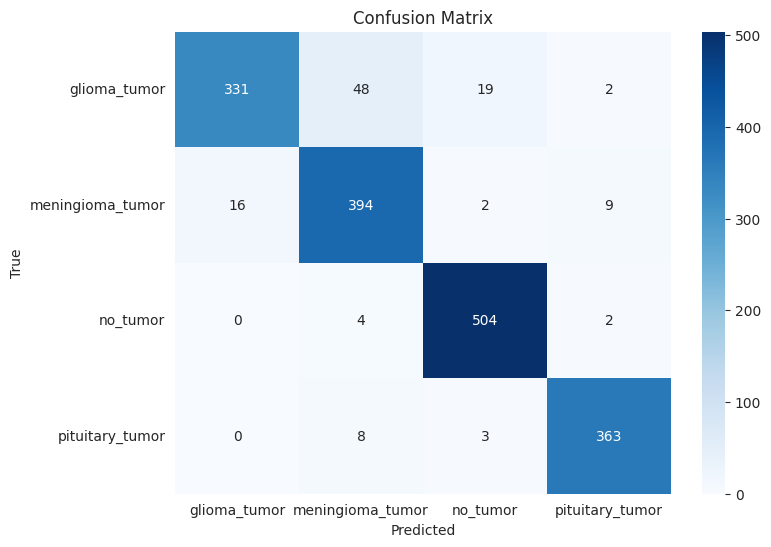

                  precision    recall  f1-score   support

    glioma_tumor       0.95      0.83      0.89       400
meningioma_tumor       0.87      0.94      0.90       421
        no_tumor       0.95      0.99      0.97       510
 pituitary_tumor       0.97      0.97      0.97       374

        accuracy                           0.93      1705
       macro avg       0.94      0.93      0.93      1705
    weighted avg       0.94      0.93      0.93      1705



In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. Get true labels and predictions
y_true = np.concatenate([y for x, y in test_ds_vgg], axis=0)   # one-hot labels
y_true = np.argmax(y_true, axis=1)  # convert one-hot to class indices

y_pred_probs = vgg_test.predict(test_ds_vgg)
y_pred = np.argmax(y_pred_probs, axis=1)

# 2. Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# 3. Get class names from dataset
class_names = test_ds.class_names   # same order as dataset

# 4. Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# 5. Print detailed report
print(classification_report(y_true, y_pred, target_names=class_names))


In [8]:
import pandas as pd

# CSV with per-sample true vs predicted labels
df_preds = pd.DataFrame({
    "True_Label": [class_names[i] for i in y_true],
    "Predicted_Label": [class_names[i] for i in y_pred]
})
df_preds.to_csv("vgg_predictions.csv", index=False)

# Confusion matrix as a CSV (rows=True, cols=Predicted)
df_cm = pd.DataFrame(cm, index=class_names, columns=class_names)
df_cm.index.name = "True_Label"
df_cm.columns.name = "Predicted_Label"
df_cm.to_csv("vgg_confusion_matrix.csv")

print("Saved: vgg_predictions.csv, vgg_confusion_matrix.csv")

Saved: vgg_predictions.csv, vgg_confusion_matrix.csv
